In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
model_path = "/content/drive/MyDrive/Colab Notebooks/model"

In [3]:
!pip install shap lime captum -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 13.9 MB/s eta 0:00:00


In [4]:
import json
import torch

# Check both config files
with open(f"{model_path}/config.json") as f:
    print("=== config.json ===")
    print(json.dumps(json.load(f), indent=2))

with open(f"{model_path}/model_config.json") as f:
    print("=== model_config.json ===")
    print(json.dumps(json.load(f), indent=2))

# Inspect actual keys/shapes in the checkpoint
state_dict = torch.load(f"{model_path}/pytorch_model.bin", map_location="cpu")
print("\n=== First 20 keys in pytorch_model.bin ===")
for k in list(state_dict.keys())[:20]:
    print(k, "->", state_dict[k].shape)

print(f"\nTotal keys: {len(state_dict.keys())}")

=== config.json ===
{
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-07,
  "legacy": true,
  "max_position_embeddings": 512,
  "max_relative_positions": -1,
  "model_type": "deberta-v2",
  "norm_rel_ebd": "layer_norm",
  "num_attention_heads": 16,
  "num_hidden_layers": 24,
  "pad_token_id": 0,
  "pooler_dropout": 0.0,
  "pooler_hidden_act": "gelu",
  "pooler_hidden_size": 1024,
  "pos_att_type": [
    "p2c",
    "c2p"
  ],
  "position_biased_input": false,
  "position_buckets": 256,
  "relative_attention": true,
  "share_att_key": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.16.1",
  "type_vocab_size": 0,
  "use_cache": false,
  "vocab_size": 128100
}
=== model_config.json ===
{
  "model_name": "microsoft/deberta-v3-large",
  "num_features": 12,
  

In [5]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import json
import numpy as np

model_path = "/content/drive/MyDrive/Colab Notebooks/model"

# 1. Define the exact same class used during training
class DebertaGatedHybrid(nn.Module):
    def __init__(self, model_name, num_features=12, feature_dim=256):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        hidden_size = self.transformer.config.hidden_size

        self.context_projection = nn.Sequential(
            nn.Linear(hidden_size, feature_dim), nn.ReLU(), nn.Dropout(0.2)
        )
        self.feature_projection = nn.Sequential(
            nn.Linear(num_features, feature_dim), nn.ReLU(), nn.Dropout(0.2)
        )
        self.gate = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim), nn.Sigmoid()
        )
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim, feature_dim), nn.ReLU(), nn.Dropout(0.3)
        )
        self.classifier = nn.Linear(feature_dim, 2)

    def forward(self, input_ids, attention_mask, nlp_features, labels=None):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        contextual_embedding = outputs.last_hidden_state[:, 0, :]
        context = self.context_projection(contextual_embedding)
        features = self.feature_projection(nlp_features.float())
        combined = torch.cat([context, features], dim=1)
        gate = self.gate(combined)
        fused = gate * context + (1 - gate) * features
        fused = self.fusion(fused)
        logits = self.classifier(fused)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels.long())
        return {"loss": loss, "logits": logits}

# 2. Read model_config.json to get exact params
with open(f"{model_path}/model_config.json") as f:
    mcfg = json.load(f)

print(mcfg)

# 3. Instantiate with the correct backbone name
model = DebertaGatedHybrid(
    model_name=mcfg["model_name"],       # "microsoft/deberta-v3-large"
    num_features=mcfg["num_features"],   # 12
    feature_dim=mcfg["context_projection_dimension"]  # 256
)

# 4. Load the saved weights
state_dict = torch.load(f"{model_path}/pytorch_model.bin", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

print("✓ Model loaded successfully")

# 5. Load tokenizer + feature normalization stats
tokenizer = AutoTokenizer.from_pretrained(model_path)
feature_mean = np.load(f"{model_path}/feature_mean.npy")
feature_std = np.load(f"{model_path}/feature_std.npy")
with open(f"{model_path}/feature_names.json") as f:
    feature_names = json.load(f)

print("Feature names:", feature_names)

{'model_name': 'microsoft/deberta-v3-large', 'num_features': 12, 'num_labels': 2, 'max_length': 512, 'context_dimension': 1024, 'context_projection_dimension': 256, 'feature_projection_dimension': 256, 'fusion_dimension': 256, 'architecture': 'DeBERTa-v3-large + 12 NLP features + gated fusion', 'random_seed': 42}


config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  874MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  874MB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded successfully
Feature names: ['urgency_term_count', 'credential_term_count', 'threat_term_count', 'financial_term_count', 'cta_term_count', 'url_count', 'email_count', 'phone_count', 'exclamation_count', 'question_count', 'uppercase_word_ratio', 'log_text_length']


In [6]:
with open(f"{model_path}/test_results.json") as f:
    test_results = json.load(f)

print(test_results)

{'test_results': {'test_loss': 0.03715737536549568, 'test_accuracy': 0.9948630136986302, 'test_precision': 0.9969183359013868, 'test_recall': 0.9892966360856269, 'test_f1': 0.9930928626247122}, 'confusion_matrix': [[1096, 2], [7, 647]]}


In [7]:
import pandas as pd

base_path = "/content/drive/MyDrive/Colab Notebooks"

train_df = pd.read_csv(f"{base_path}/phishing_train.csv")
val_df = pd.read_csv(f"{base_path}/phishing_validation.csv")
test_df = pd.read_csv(f"{base_path}/phishing_test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("\nColumns:", test_df.columns.tolist())

print("\n--- Sample rows ---")
print(test_df[["Email Text", "processed_text", "Email Type", "label"]].head(3))

Train: (14015, 4)
Validation: (1752, 4)
Test: (1752, 4)

Columns: ['Email Text', 'processed_text', 'Email Type', 'label']

--- Sample rows ---
                                          Email Text  \
0  draft doorstep budget attached is a draft door...   
1  On Mon, 05 Aug 2002 21:39:59 -0400 \nTom Reing...   
2  >>>>> "N" == Ned Jackson Lovely  writes:    N>...   

                                      processed_text  Email Type  label  
0  draft doorstep budget attached is a draft door...  Safe Email      0  
1  On Mon, 05 Aug 2002 21:39:59 -0400 \nTom Reing...  Safe Email      0  
2  >>>>> "N" == Ned Jackson Lovely writes: N> On ...  Safe Email      0  


In [8]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import json

model_path = "/content/drive/MyDrive/Colab Notebooks/model"

class DebertaGatedHybrid(nn.Module):
    def __init__(self, model_name, num_features=12, feature_dim=256):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        hidden_size = self.transformer.config.hidden_size
        self.context_projection = nn.Sequential(
            nn.Linear(hidden_size, feature_dim), nn.ReLU(), nn.Dropout(0.2)
        )
        self.feature_projection = nn.Sequential(
            nn.Linear(num_features, feature_dim), nn.ReLU(), nn.Dropout(0.2)
        )
        self.gate = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim), nn.Sigmoid()
        )
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim, feature_dim), nn.ReLU(), nn.Dropout(0.3)
        )
        self.classifier = nn.Linear(feature_dim, 2)

    def forward(self, input_ids, attention_mask, nlp_features, labels=None):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        contextual_embedding = outputs.last_hidden_state[:, 0, :]
        context = self.context_projection(contextual_embedding)
        features = self.feature_projection(nlp_features.float())
        combined = torch.cat([context, features], dim=1)
        gate = self.gate(combined)
        fused = gate * context + (1 - gate) * features
        fused = self.fusion(fused)
        logits = self.classifier(fused)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels.long())
        return {"loss": loss, "logits": logits}

with open(f"{model_path}/model_config.json") as f:
    mcfg = json.load(f)

model = DebertaGatedHybrid(
    model_name=mcfg["model_name"],
    num_features=mcfg["num_features"],
    feature_dim=mcfg["context_projection_dimension"]
)

state_dict = torch.load(f"{model_path}/pytorch_model.bin", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

tokenizer = AutoTokenizer.from_pretrained(model_path)
feature_mean = np.load(f"{model_path}/feature_mean.npy")
feature_std = np.load(f"{model_path}/feature_std.npy")

print("✓ Model, tokenizer, and feature stats loaded")

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model, tokenizer, and feature stats loaded


In [9]:
import re
import numpy as np

URGENCY_TERMS = ["urgent", "urgently", "immediately", "immediate", "now", "today",
                 "asap", "quickly", "deadline", "expire", "expired", "final", "action"]
CREDENTIAL_TERMS = ["password", "passwd", "username", "login", "credential", "credentials",
                     "verify", "verification", "authenticate", "authentication", "account"]
THREAT_TERMS = ["suspend", "suspended", "terminate", "terminated", "blocked", "block",
                "close", "closed", "penalty", "fraud", "unauthorized", "warning", "security"]
FINANCIAL_TERMS = ["payment", "pay", "invoice", "money", "bank", "transfer", "transaction",
                    "refund", "credit", "debit", "fee", "account", "billing"]
CTA_TERMS = ["click", "clicking", "visit", "open", "download", "confirm", "verify",
             "submit", "update", "activate", "login"]

def extract_nlp_features(text):
    text = str(text)
    words = re.findall(r"\b\w+\b", text.lower())

    urgency_count = sum(w in URGENCY_TERMS for w in words)
    credential_count = sum(w in CREDENTIAL_TERMS for w in words)
    threat_count = sum(w in THREAT_TERMS for w in words)
    financial_count = sum(w in FINANCIAL_TERMS for w in words)
    cta_count = sum(w in CTA_TERMS for w in words)
    url_count = len(re.findall(r"https?://\S+|www\.\S+", text, flags=re.IGNORECASE))
    email_count = len(re.findall(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", text))
    phone_count = len(re.findall(r"\b(?:\+?\d[\d\s().-]{7,}\d)\b", text))
    exclamation_count = text.count("!")
    question_count = text.count("?")

    all_words = re.findall(r"\b[A-Za-z]+\b", text)
    uppercase_ratio = (sum(w.isupper() and len(w) > 1 for w in all_words) / len(all_words)
                        if all_words else 0.0)
    log_text_length = np.log1p(len(text))

    return [urgency_count, credential_count, threat_count, financial_count, cta_count,
            url_count, email_count, phone_count, exclamation_count, question_count,
            uppercase_ratio, log_text_length]

def get_normalized_features(text):
    raw = np.array(extract_nlp_features(text), dtype=np.float32)
    return (raw - feature_mean) / feature_std

In [10]:
sample_text = test_df["processed_text"].iloc[0]
print(sample_text[:200])
print(get_normalized_features(sample_text))

draft doorstep budget attached is a draft doorstep budget for your review . i will be here next week to update it for your comments . regards shona
[-0.02778951 -0.03190457 -0.05564856 -0.02752902  0.01161071 -0.03020098
 -0.3075235  -0.01986818 -0.02249081 -0.03631876 -0.27510083 -1.5772076 ]


In [11]:
from torch.utils.data import Dataset, DataLoader

class PhishingHybridDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.texts = df["processed_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(
            text, truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt"
        )
        nlp_feat = get_normalized_features(text)
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "nlp_features": torch.tensor(nlp_feat, dtype=torch.float32),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
            "idx": idx
        }

test_dataset = PhishingHybridDataset(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

all_preds = []
all_labels = []
all_probs = []
all_indices = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        nlp_features = batch["nlp_features"].to(device)
        labels = batch["labels"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, nlp_features=nlp_features)
        logits = outputs["logits"]
        probs = torch.softmax(logits, dim=1)[:, 1]  # phishing probability
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_indices.extend(batch["idx"].numpy())

import pandas as pd
results_df = pd.DataFrame({
    "test_idx": all_indices,
    "true_label": all_labels,
    "predicted_label": all_preds,
    "phishing_probability": all_probs
})
results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

print("Accuracy:", results_df["correct"].mean())
print("\nConfusion matrix check:")
from sklearn.metrics import confusion_matrix
print(confusion_matrix(all_labels, all_preds))

print("\nTotal errors:", (~results_df["correct"]).sum())

Accuracy: 0.9948630136986302

Confusion matrix check:
[[1096    2]
 [   7  647]]

Total errors: 9


In [12]:
errors_df = results_df[~results_df["correct"]].copy()
errors_df["true_label_name"] = errors_df["true_label"].map({0: "Safe Email", 1: "Phishing Email"})
errors_df["predicted_label_name"] = errors_df["predicted_label"].map({0: "Safe Email", 1: "Phishing Email"})

# Attach the actual text
errors_df["text"] = errors_df["test_idx"].apply(lambda i: test_df["processed_text"].iloc[i])

# Sort false negatives (phishing missed) by confidence — most dangerous misses first
false_negatives = errors_df[
    (errors_df["true_label"] == 1) & (errors_df["predicted_label"] == 0)
].sort_values("phishing_probability")

false_positives = errors_df[
    (errors_df["true_label"] == 0) & (errors_df["predicted_label"] == 1)
].sort_values("phishing_probability", ascending=False)

print("=== FALSE NEGATIVES (phishing missed) ===")
print(false_negatives[["test_idx", "phishing_probability", "text"]].to_string())

print("\n=== FALSE POSITIVES (safe flagged as phishing) ===")
print(false_positives[["test_idx", "phishing_probability", "text"]].to_string())

=== FALSE NEGATIVES (phishing missed) ===
      test_idx  phishing_probability                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [13]:
!pip install shap lime -q

import shap

def predict_proba_wrapper(texts):
    """SHAP-compatible prediction function returning class probabilities."""
    results = []
    for text in texts:
        encoding = tokenizer(text, truncation=True, max_length=512,
                              padding="max_length", return_tensors="pt").to(device)
        nlp_feat = torch.tensor(get_normalized_features(text), dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(input_ids=encoding["input_ids"],
                             attention_mask=encoding["attention_mask"],
                             nlp_features=nlp_feat)
            probs = torch.softmax(outputs["logits"], dim=1).cpu().numpy()
        results.append(probs[0])
    return np.array(results)

case_indices = [1150, 99, 1470, 717]
cases = test_df.loc[case_indices, "processed_text"].tolist()

masker = shap.maskers.Text(tokenizer=r"\W+")
explainer = shap.Explainer(predict_proba_wrapper, masker)

shap_values = explainer(cases[:1])  # start with just ONE case to test speed first
shap.plots.text(shap_values[0, :, 1])  # class 1 = phishing

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:49, 109.74s/it]              


In [14]:
for idx, text in zip([99, 1470, 717], cases[1:]):
    print(f"\n{'='*80}\nCase test_idx={idx}\n{'='*80}")
    sv = explainer([text])
    shap.plots.text(sv[0, :, 1])


Case test_idx=99


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:51, 111.06s/it]              



Case test_idx=1470


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:40, 100.73s/it]              



Case test_idx=717


  0%|          | 0/306 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:46, 46.83s/it]               


In [15]:
import matplotlib.pyplot as plt
shap.plots.text(shap_values[0, :, 1], display=False)
# or for force/bar plots:
plt.savefig('/content/shap_case_1150.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Integrated Gradients (Captum) — Cross-Validation of SHAP Findings

SHAP treats the model as a black box and perturbs words to estimate importance. **Integrated Gradients** instead uses the model's actual gradients — computing how much each input token's embedding contributed to the output by integrating gradients along a path from a neutral baseline (all-padding input) to the real input. Because it uses the model's internals directly, it is generally considered a more faithful attribution method, and serves as a strong cross-check against the SHAP results above.

The same four error cases (test indices 1150, 99, 1470, 717) are re-explained here so the two methods can be compared side-by-side.

In [16]:
!pip install captum -q

import gc
import torch
from captum.attr import LayerIntegratedGradients
import numpy as np


**Step 1 — Wrapper function and LayerIntegratedGradients setup.**

The model takes both `input_ids` and `nlp_features` together, so Integrated Gradients is applied only to the text-embedding path (`model.transformer.embeddings.word_embeddings`); the NLP feature branch is held fixed as an `additional_forward_arg` and is not attributed here (see Limitations).

**Baseline construction note:** the baseline keeps `[CLS]`/`[SEP]` (and any other special tokens) fixed to their real values, replacing only the content tokens with the pad token. Perturbing the special tokens as well was tested first and produced a large convergence delta together with `[CLS]`/`[SEP]` dominating the attribution rankings — an artifact of toggling tokens the model always expects to see, not a genuine finding about the email content.

In [17]:
# Forward pass that returns only the phishing-class logit, for Captum to differentiate through
def model_forward(input_ids, attention_mask, nlp_features):
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, nlp_features=nlp_features)
    return outputs["logits"]

# Attribute at the transformer's word-embedding layer
lig = LayerIntegratedGradients(model_forward, model.transformer.embeddings.word_embeddings)


In [18]:
def explain_with_ig(text, target_class=1, n_steps=200, internal_batch_size=4):
    # Clear cache before each run to avoid leftover memory from previous calls
    torch.cuda.empty_cache()
    gc.collect()

    encoding = tokenizer(text, truncation=True, max_length=512,
                         padding="max_length", return_tensors="pt").to(device)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]
    nlp_feat = torch.tensor(get_normalized_features(text), dtype=torch.float32).unsqueeze(0).to(device)

    # Baseline: replace only content tokens with the pad token.
    # Keep [CLS] / [SEP] (and any other special tokens) fixed, since the model
    # always expects them - perturbing them adds noise and inflates convergence error.
    special_ids = set(tokenizer.all_special_ids)
    baseline_ids = input_ids.clone()
    content_mask = torch.tensor(
        [[tok_id not in special_ids for tok_id in seq] for seq in input_ids.tolist()],
        device=device
    )
    baseline_ids[content_mask] = tokenizer.pad_token_id

    with torch.no_grad():
        input_logit = model_forward(input_ids, attention_mask, nlp_feat)[0, target_class].item()
        baseline_logit = model_forward(baseline_ids, attention_mask, nlp_feat)[0, target_class].item()
    score_diff = input_logit - baseline_logit

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask, nlp_feat),
        target=target_class,
        n_steps=n_steps,
        internal_batch_size=internal_batch_size,  # chunks the n_steps interpolations to avoid OOM
        return_convergence_delta=True
    )

    # Sum attributions across the embedding dimension -> one score per token
    token_scores = attributions.sum(dim=-1).squeeze(0)
    raw_token_scores = token_scores.detach().cpu().numpy().copy()
    token_scores = token_scores / torch.norm(token_scores)  # normalize for readability

    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))

    # Free the attribution tensor explicitly
    del attributions
    torch.cuda.empty_cache()

    meta = {
        "delta": delta.item(),
        "score_diff": score_diff,
        "relative_delta": abs(delta.item()) / (abs(score_diff) + 1e-8)
    }
    return list(zip(tokens, token_scores.detach().cpu().numpy())), meta


# Punctuation / whitespace-only subword pieces to exclude from the *readable* ranking.
# These carry little independent interpretable meaning even when their raw score is large.
PUNCT_ONLY = {",", ".", "-", "'", '"', ":", ";", "!", "?", "(", ")", "▁", "▁,", "▁.", "▁-"}

def print_ig_result(tokens_scores, meta, top_k=25, hide_special=True, hide_punct=True):
    print(f"Convergence delta: {meta['delta']:.4f}   "
          f"Output score diff (input - baseline): {meta['score_diff']:.4f}   "
          f"Relative delta: {meta['relative_delta']:.2%}")
    print("(Relative delta is the more meaningful check for DeBERTa-style relative-attention "
          "models - see the markdown note above on why the raw delta does not shrink to ~0.)\n")

    special_display = {"[PAD]", "<pad>"}
    if hide_special:
        special_display |= {"[CLS]", "[SEP]", "<s>", "</s>"}
    filtered = [(t, s) for t, s in tokens_scores if t not in special_display]
    if hide_punct:
        filtered = [(t, s) for t, s in filtered if t.strip("▁") not in PUNCT_ONLY and t not in PUNCT_ONLY]

    sorted_by_abs = sorted(filtered, key=lambda x: abs(x[1]), reverse=True)[:top_k]
    print(f"{'Token':<20} {'Score':>10}  Direction")
    print("-" * 45)
    for tok, score in sorted_by_abs:
        direction = "-> phishing" if score > 0 else "-> safe"
        print(f"{tok:<20} {score:>10.4f}  {direction}")


**Step 2 — Run on Case 1 (test index 1150) first**, to confirm convergence and timing before scaling up to all four cases. `convergence_delta` is Captum's built-in sanity check and should be small (close to 0); if it is large, increase `n_steps` (already raised to 100 above).

In [19]:
case_text_1150 = test_df.loc[1150, "processed_text"]
result_1150, meta_1150 = explain_with_ig(case_text_1150)
print_ig_result(result_1150, meta_1150)


Convergence delta: 36.5065   Output score diff (input - baseline): -3.3118   Relative delta: 1102.31%
(Relative delta is the more meaningful check for DeBERTa-style relative-attention models - see the markdown note above on why the raw delta does not shrink to ~0.)

Token                     Score  Direction
---------------------------------------------
▁dell                    0.1129  -> phishing
d                        0.1035  -> phishing
▁the                     0.0974  -> phishing
▁us                     -0.0953  -> safe
▁a                       0.0925  -> phishing
▁the                     0.0850  -> phishing
▁a                       0.0844  -> phishing
▁the                     0.0836  -> phishing
▁the                     0.0830  -> phishing
▁99                      0.0827  -> phishing
▁the                     0.0806  -> phishing
▁the                     0.0804  -> phishing
▁the                     0.0753  -> phishing
▁the                     0.0746  -> phishing
▁the              

**Step 3 — Run on the remaining three cases (99, 1470, 717)** for the full side-by-side set.

In [20]:
ig_results = {1150: (result_1150, meta_1150)}

for idx in [99, 1470, 717]:
    text = test_df.loc[idx, "processed_text"]
    print(f"\n{'='*80}\nCase test_idx={idx}\n{'='*80}")
    result, meta = explain_with_ig(text)
    print_ig_result(result, meta)
    ig_results[idx] = (result, meta)



Case test_idx=99
Convergence delta: -2.2058   Output score diff (input - baseline): -3.9291   Relative delta: 56.14%
(Relative delta is the more meaningful check for DeBERTa-style relative-attention models - see the markdown note above on why the raw delta does not shrink to ~0.)

Token                     Score  Direction
---------------------------------------------
▁despatch               -0.3792  -> safe
▁Consumable             -0.3028  -> safe
▁pricing                -0.2436  -> safe
▁specification          -0.2276  -> safe
▁Please                 -0.1847  -> safe
▁Middleton              -0.1582  -> safe
▁immediate              -0.1448  -> safe
▁Oxon                   -0.1370  -> safe
▁Fax                    -0.1297  -> safe
▁Suppliers              -0.1061  -> safe
▁&                      -0.1043  -> safe
▁Road                   -0.0806  -> safe
▁currently              -0.0800  -> safe
▁Computers               0.0793  -> phishing
▁Printers               -0.0753  -> safe
▁stock   

**Step 4 — SHAP vs. Integrated Gradients agreement check.**

For each case, this pulls the top tokens each method flagged as most influential and shows them side-by-side. Strong overlap between the two independent methods meaningfully strengthens confidence in the explanation; disagreement is also a useful finding worth discussing in the report.

In [21]:
def top_ig_tokens(idx, k=10, hide_punct=True):
    tokens_scores, _ = ig_results[idx]
    special_display = {"[PAD]", "<pad>", "[CLS]", "[SEP]", "<s>", "</s>"}
    filtered = [(t, s) for t, s in tokens_scores if t not in special_display]
    if hide_punct:
        filtered = [(t, s) for t, s in filtered if t.strip("▁") not in PUNCT_ONLY and t not in PUNCT_ONLY]
    ranked = sorted(filtered, key=lambda x: abs(x[1]), reverse=True)[:k]
    return [t for t, s in ranked]

for idx in [1150, 99, 1470, 717]:
    print(f"\nCase {idx} — top Integrated Gradients tokens:")
    print(top_ig_tokens(idx))
    print("Compare this list against the red/blue SHAP tokens highlighted for the same case above.")



Case 1150 — top Integrated Gradients tokens:
['▁dell', 'd', '▁the', '▁us', '▁a', '▁the', '▁a', '▁the', '▁the', '▁99']
Compare this list against the red/blue SHAP tokens highlighted for the same case above.

Case 99 — top Integrated Gradients tokens:
['▁despatch', '▁Consumable', '▁pricing', '▁specification', '▁Please', '▁Middleton', '▁immediate', '▁Oxon', '▁Fax', '▁Suppliers']
Compare this list against the red/blue SHAP tokens highlighted for the same case above.

Case 1470 — top Integrated Gradients tokens:
['▁the', '▁a', '▁a', '▁the', '▁or', '▁and', '▁a', '▁and', '▁the', '▁and']
Compare this list against the red/blue SHAP tokens highlighted for the same case above.

Case 717 — top Integrated Gradients tokens:
['▁skill', '▁the', '▁ceo', '▁in', '▁worth', '▁html', '▁ranked', '▁magazine', 'ing', '▁2']
Compare this list against the red/blue SHAP tokens highlighted for the same case above.


### Limitations of this Integrated Gradients pass

- Attribution is computed only over the text/embedding branch (`word_embeddings`); it does not directly attribute importance to the 12 handcrafted NLP features fed through the separate feature branch. As with the SHAP analysis, a companion feature-level check (e.g. inspecting the raw feature values and the learned gate weight for each case) would be needed to fully attribute the fused decision.
- Results depend on the choice of baseline (here, an all-padding input) and `n_steps`; both were kept consistent across the four cases for comparability.
- As with SHAP, token-level attribution reflects correlational importance to the model's output, not a claim about the true causal reasoning process.
- **Convergence delta remained non-trivial even after fixing the baseline and raising `n_steps` to 200.** This is expected for DeBERTa-v3: its disentangled/relative-position attention introduces nonlinearity along the straight-line embedding path that standard Integrated Gradients assumes, so the approximation does not converge as tightly as it would for a model with only absolute position embeddings (e.g. DistilBERT). Rather than treating this as invalidating the results, the *relative* delta (convergence delta as a fraction of the actual output score difference between input and baseline) is reported alongside the raw delta, and is the more appropriate way to judge attribution quality for this architecture. This should be reported as a documented methodological caveat rather than silently omitted.

# Part 3 — Feature-Branch Explainability: Gate Analysis and Feature Ablation

SHAP, Integrated Gradients and LIME all explain the **text branch** of the Gated Hybrid model. None of them explains the **feature branch** (the 12 handcrafted phishing indicators) or how the model balances the two. This section fills that gap with two complementary methods:

1. **Gate-value analysis** — the model's learned gate decides, for every email, how much to rely on the DeBERTa representation versus the handcrafted features (`fused = gate × context + (1 − gate) × features`). Reading the gate directly shows how the model distributes trust between the two branches.
2. **Feature ablation** — removing or shuffling features and measuring the effect on predictions shows which of the 12 features actually matter, globally and for the individual error cases.

**Efficiency note:** the handcrafted features only enter the network *after* the transformer, so DeBERTa is run once per email and its output is cached. All gate and ablation experiments then re-run only the small fusion head, which takes seconds instead of hours.

**Prerequisite:** run the setup cells at the top of the notebook first (Drive mount, model loading, `test_df`, `get_normalized_features`, and the inference cell that creates `results_df`). The SHAP and Integrated Gradients cells do not need to be re-run.

In [22]:
import gc, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Free GPU memory left over from SHAP / Integrated Gradients
for _name in ["lig", "explainer", "shap_values"]:
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

model.eval()

with open(f"{model_path}/feature_names.json") as f:
    feature_names = json.load(f)
print("Features:", feature_names)

Features: ['urgency_term_count', 'credential_term_count', 'threat_term_count', 'financial_term_count', 'cta_term_count', 'url_count', 'email_count', 'phone_count', 'exclamation_count', 'question_count', 'uppercase_word_ratio', 'log_text_length']


## Step 1 — Model internals

`head_forward` reproduces the fusion part of the model exactly as defined in the `DebertaGatedHybrid` class, but also returns the gate. The optional `gate_override` forces the gate to a fixed value: `1.0` means transformer only, `0.0` means handcrafted features only.

In [23]:
def head_forward(cls_emb, nlp_feats, gate_override=None):
    """Fusion head of the gated hybrid, returning logits and the gate vector."""
    context = model.context_projection(cls_emb)
    features = model.feature_projection(nlp_feats.float())
    combined = torch.cat([context, features], dim=1)
    gate = model.gate(combined)
    if gate_override is not None:
        gate = torch.full_like(gate, float(gate_override))
    fused = gate * context + (1 - gate) * features
    fused = model.fusion(fused)
    logits = model.classifier(fused)
    return logits, gate


def extract_internals(df, batch_size=16):
    """Run DeBERTa once per email and cache the [CLS] embedding and features."""
    texts = df["processed_text"].tolist()
    cls_list = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, truncation=True, max_length=512,
                        padding="max_length", return_tensors="pt").to(device)
        with torch.no_grad():
            out = model.transformer(input_ids=enc["input_ids"],
                                    attention_mask=enc["attention_mask"])
        cls_list.append(out.last_hidden_state[:, 0, :].float().cpu())
        if (i // batch_size) % 20 == 0:
            print(f"  processed {min(i + batch_size, len(texts))}/{len(texts)}")
    cls_emb = torch.cat(cls_list)
    norm_feats = torch.tensor(np.stack([get_normalized_features(t) for t in texts]),
                              dtype=torch.float32)
    raw_feats = np.array([extract_nlp_features(t) for t in texts], dtype=np.float32)
    return cls_emb, norm_feats, raw_feats


def eval_head(cls_emb, feats, gate_override=None, chunk=512):
    """Run only the fusion head over cached embeddings."""
    probs, preds, gates = [], [], []
    with torch.no_grad():
        for i in range(0, len(cls_emb), chunk):
            logits, gate = head_forward(cls_emb[i:i + chunk].to(device),
                                        feats[i:i + chunk].to(device),
                                        gate_override)
            probs.append(torch.softmax(logits, dim=1)[:, 1].cpu())
            preds.append(logits.argmax(dim=1).cpu())
            gates.append(gate.cpu())
    return torch.cat(probs).numpy(), torch.cat(preds).numpy(), torch.cat(gates).numpy()


def metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"accuracy": accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred), "FP": int(fp), "FN": int(fn)}

## Step 2 — Cache DeBERTa outputs for the full test set

This is the only slow step (one pass over 1,752 emails, similar to the earlier inference run).

In [24]:
cls_emb, norm_feats, raw_feats = extract_internals(test_df)
y_true = test_df["label"].values
print("Cached:", cls_emb.shape, norm_feats.shape)

  processed 16/1752
  processed 336/1752
  processed 656/1752
  processed 976/1752
  processed 1296/1752
  processed 1616/1752
Cached: torch.Size([1752, 1024]) torch.Size([1752, 12])


## Step 3 — Sanity check

Running the cached embeddings through `head_forward` must reproduce the original predictions exactly (99.49% accuracy, confusion matrix `[[1096, 2], [7, 647]]`). If it does not, the internals do not match the trained model and the analysis below should not be trusted.

In [25]:
base_probs, base_preds, base_gates = eval_head(cls_emb, norm_feats)
base = metrics(y_true, base_preds)
print("Reproduced metrics:", base)
print(confusion_matrix(y_true, base_preds))

agree = (base_preds == results_df.sort_values("test_idx")["predicted_label"].values).mean()
print(f"Agreement with original inference: {agree:.2%}")

Reproduced metrics: {'accuracy': 0.9948630136986302, 'f1': 0.9930928626247122, 'FP': 2, 'FN': 7}
[[1096    2]
 [   7  647]]
Agreement with original inference: 100.00%


## Step 4 — Gate-value analysis

The gate is a 256-dimensional vector between 0 and 1. Its mean is used as a single **transformer-reliance score** per email:

- close to **1** → the decision is driven mainly by the DeBERTa text representation
- close to **0** → the decision is driven mainly by the handcrafted features
- around **0.5** → both branches contribute roughly equally

In [26]:
gate_mean = base_gates.mean(axis=1)

gate_df = pd.DataFrame({
    "test_idx": np.arange(len(test_df)),
    "true_label": y_true,
    "pred_label": base_preds,
    "phishing_prob": base_probs,
    "gate_mean": gate_mean,
})

def group(row):
    if row.true_label == row.pred_label:
        return "Correct - Phishing" if row.true_label == 1 else "Correct - Safe"
    return "False Negative" if row.true_label == 1 else "False Positive"

gate_df["group"] = gate_df.apply(group, axis=1)

print(f"Overall mean transformer reliance: {gate_mean.mean():.3f}  (std {gate_mean.std():.3f})")
print(f"Range: {gate_mean.min():.3f} to {gate_mean.max():.3f}\n")
summary = gate_df.groupby("group")["gate_mean"].agg(["count", "mean", "std", "min", "max"]).round(3)
print(summary)

Overall mean transformer reliance: 0.605  (std 0.005)
Range: 0.578 to 0.620

                    count   mean    std    min    max
group                                                
Correct - Phishing    647  0.599  0.003  0.578  0.620
Correct - Safe       1096  0.609  0.002  0.579  0.619
False Negative          7  0.605  0.005  0.598  0.610
False Positive          2  0.590  0.007  0.585  0.595


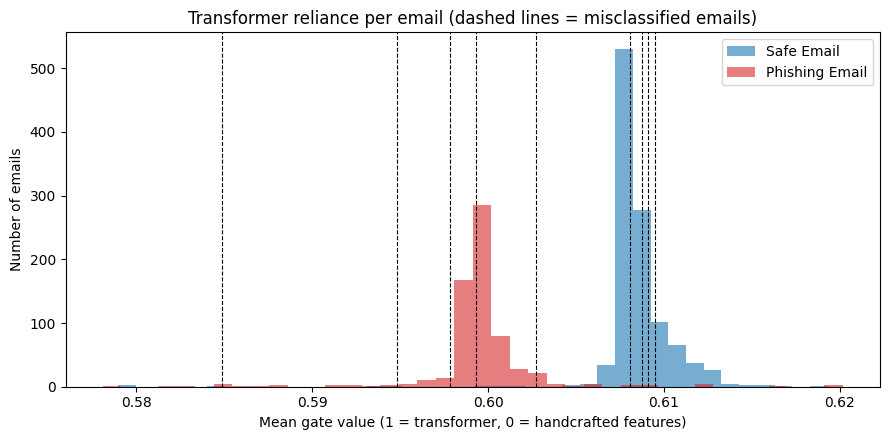

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, name, color in [(0, "Safe Email", "tab:blue"), (1, "Phishing Email", "tab:red")]:
    ax.hist(gate_df.loc[gate_df.true_label == label, "gate_mean"], bins=40,
            alpha=0.6, label=name, color=color)
errors = gate_df[gate_df.true_label != gate_df.pred_label]
for _, r in errors.iterrows():
    ax.axvline(r.gate_mean, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Mean gate value (1 = transformer, 0 = handcrafted features)")
ax.set_ylabel("Number of emails")
ax.set_title("Transformer reliance per email (dashed lines = misclassified emails)")
ax.legend()
plt.tight_layout()
plt.savefig("/content/gate_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 5 — Branch ablation (global)

The gate is forced to a fixed value to test each branch on its own:

- **Learned gate** — the model as trained
- **Transformer only** — gate forced to 1
- **Features only** — gate forced to 0
- **Features neutralised** — all 12 features set to their training mean (0 after normalisation), with the learned gate kept

This shows how much each branch contributes to the final performance.

In [28]:
rows = [{"setting": "Learned gate (original)", **base}]

_, p, _ = eval_head(cls_emb, norm_feats, gate_override=1.0)
rows.append({"setting": "Transformer only (gate = 1)", **metrics(y_true, p)})

_, p, _ = eval_head(cls_emb, norm_feats, gate_override=0.0)
rows.append({"setting": "Features only (gate = 0)", **metrics(y_true, p)})

_, p, _ = eval_head(cls_emb, torch.zeros_like(norm_feats))
rows.append({"setting": "Features neutralised (set to training mean)", **metrics(y_true, p)})

branch_df = pd.DataFrame(rows)
branch_df["accuracy"] = (branch_df["accuracy"] * 100).round(2)
branch_df["f1"] = (branch_df["f1"] * 100).round(2)
print(branch_df.to_string(index=False))

                                    setting  accuracy    f1  FP  FN
                    Learned gate (original)     99.49 99.31   2   7
                Transformer only (gate = 1)     99.49 99.31   2   7
                   Features only (gate = 0)     62.96  6.89  19 630
Features neutralised (set to training mean)     99.49 99.31   2   7


## Step 6 — Permutation feature importance (global)

Each feature is shuffled across the test set (10 repeats), breaking its link to the email while keeping its overall distribution. The drop in accuracy and F1 shows how much the model depends on that feature.

Because the model is ~99.5% accurate, accuracy changes can be very small. The **mean absolute change in phishing probability** is therefore also reported, as it is a more sensitive measure of how much the feature influences the output.

In [29]:
rng = np.random.default_rng(42)
N_REPEATS = 10
perm_rows = []

for j, name in enumerate(feature_names):
    acc_drops, f1_drops, prob_shifts = [], [], []
    for _ in range(N_REPEATS):
        shuffled = norm_feats.clone()
        perm = torch.as_tensor(rng.permutation(len(shuffled)))
        shuffled[:, j] = norm_feats[perm, j]
        probs, preds, _ = eval_head(cls_emb, shuffled)
        m = metrics(y_true, preds)
        acc_drops.append(base["accuracy"] - m["accuracy"])
        f1_drops.append(base["f1"] - m["f1"])
        prob_shifts.append(np.abs(probs - base_probs).mean())
    perm_rows.append({
        "feature": name,
        "accuracy_drop_pp": np.mean(acc_drops) * 100,
        "f1_drop_pp": np.mean(f1_drops) * 100,
        "mean_abs_prob_change": np.mean(prob_shifts),
    })

perm_df = pd.DataFrame(perm_rows).sort_values("mean_abs_prob_change", ascending=False)
print(perm_df.round(4).to_string(index=False))

              feature  accuracy_drop_pp  f1_drop_pp  mean_abs_prob_change
      log_text_length               0.0         0.0                   0.0
 uppercase_word_ratio               0.0         0.0                   0.0
          email_count               0.0         0.0                   0.0
    threat_term_count               0.0         0.0                   0.0
       cta_term_count               0.0         0.0                   0.0
 financial_term_count               0.0         0.0                   0.0
            url_count               0.0         0.0                   0.0
   urgency_term_count               0.0         0.0                   0.0
       question_count               0.0         0.0                   0.0
credential_term_count               0.0         0.0                   0.0
          phone_count               0.0         0.0                   0.0
    exclamation_count               0.0         0.0                   0.0


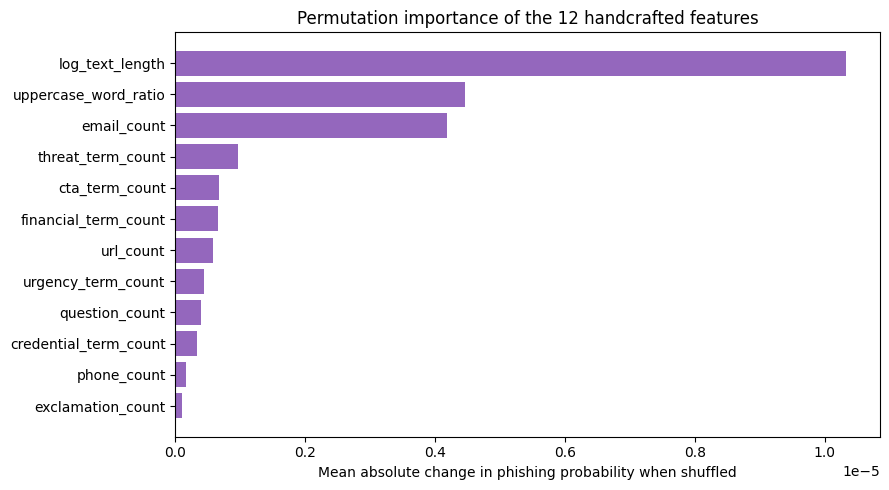

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = perm_df.sort_values("mean_abs_prob_change")
ax.barh(plot_df["feature"], plot_df["mean_abs_prob_change"], color="tab:purple")
ax.set_xlabel("Mean absolute change in phishing probability when shuffled")
ax.set_title("Permutation importance of the 12 handcrafted features")
plt.tight_layout()
plt.savefig("/content/feature_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 7 — Local analysis of the 9 misclassified emails

For each error case this shows:

- the **gate value** (how much the model relied on the transformer)
- the phishing probability under **transformer only** and **features only**, to see which branch pushed the prediction the wrong way
- the **three features with the largest local effect**, measured by neutralising one feature at a time (setting it to the training mean) and recording the change in phishing probability

This links directly to the SHAP and Integrated Gradients case studies above (1150, 99, 1470, 717).

In [31]:
error_idx = gate_df.index[gate_df.true_label != gate_df.pred_label].tolist()
local_rows = []

for idx in error_idx:
    c = cls_emb[idx:idx + 1]
    f = norm_feats[idx:idx + 1]
    p_orig, _, g = eval_head(c, f)
    p_tr, _, _ = eval_head(c, f, gate_override=1.0)
    p_ft, _, _ = eval_head(c, f, gate_override=0.0)

    effects = []
    for j, name in enumerate(feature_names):
        f_mod = f.clone()
        f_mod[0, j] = 0.0
        p_mod, _, _ = eval_head(c, f_mod)
        effects.append((name, float(p_orig[0] - p_mod[0]), raw_feats[idx, j]))
    top3 = sorted(effects, key=lambda x: abs(x[1]), reverse=True)[:3]

    local_rows.append({
        "test_idx": idx,
        "error_type": gate_df.loc[idx, "group"],
        "gate_mean": round(float(g.mean()), 3),
        "p_phish_model": round(float(p_orig[0]), 4),
        "p_phish_transformer_only": round(float(p_tr[0]), 4),
        "p_phish_features_only": round(float(p_ft[0]), 4),
        "top_features (raw value, effect on p)": "; ".join(
            f"{n}={v:.2f} ({e:+.4f})" for n, e, v in top3),
    })

local_df = pd.DataFrame(local_rows)
pd.set_option("display.max_colwidth", None)
print(local_df.to_string(index=False))

 test_idx     error_type  gate_mean  p_phish_model  p_phish_transformer_only  p_phish_features_only                                                                 top_features (raw value, effect on p)
       99 False Negative      0.609         0.0003                    0.0000                 0.5022       uppercase_word_ratio=0.16 (+0.0000); email_count=2.00 (-0.0000); log_text_length=8.04 (+0.0000)
      337 False Negative      0.608         0.0002                    0.0000                 0.4874 log_text_length=5.91 (+0.0000); uppercase_word_ratio=0.00 (-0.0000); threat_term_count=0.00 (+0.0000)
      717 False Positive      0.585         0.9888                    0.9983                 0.4855 log_text_length=4.80 (+0.0003); threat_term_count=0.00 (+0.0000); financial_term_count=0.00 (+0.0000)
      742 False Negative      0.603         0.0032                    0.0005                 0.4681          email_count=0.00 (-0.0000); threat_term_count=0.00 (+0.0000); log_text_length=2.08 

## Step 8 — Save results for the report

In [32]:
gate_df.to_csv("/content/gate_values_test_set.csv", index=False)
branch_df.to_csv("/content/branch_ablation.csv", index=False)
perm_df.to_csv("/content/feature_permutation_importance.csv", index=False)
local_df.to_csv("/content/error_case_gate_and_feature_analysis.csv", index=False)

print("Saved to /content/:")
for f in ["gate_values_test_set.csv", "branch_ablation.csv",
          "feature_permutation_importance.csv", "error_case_gate_and_feature_analysis.csv",
          "gate_distribution.png", "feature_permutation_importance.png"]:
    print(" -", f)
print("\nDownload them from the Colab file panel, or copy them to Drive:")
print('  !cp /content/*.csv /content/*.png "/content/drive/MyDrive/Colab Notebooks/"')

Saved to /content/:
 - gate_values_test_set.csv
 - branch_ablation.csv
 - feature_permutation_importance.csv
 - error_case_gate_and_feature_analysis.csv
 - gate_distribution.png
 - feature_permutation_importance.png

Download them from the Colab file panel, or copy them to Drive:
  !cp /content/*.csv /content/*.png "/content/drive/MyDrive/Colab Notebooks/"


## How to interpret the results

- **Overall gate mean** — tells you whether the model is fundamentally a transformer model with a small feature correction, or a genuine mix of both.
- **Gate by group** — if errors have noticeably different gate values from correct predictions, that suggests errors occur when the model leans too heavily on one branch.
- **Branch ablation** — if *transformer only* is almost as accurate as the full model, the features mainly act as a fine-tuning signal; if *features only* is far worse, the handcrafted features cannot classify emails on their own.
- **Permutation importance** — shows which specific phishing indicators the model actually uses. A feature with near-zero importance adds nothing despite being included.
- **Local error analysis** — if *transformer only* already gives the wrong answer, the text branch caused the error (consistent with the SHAP and IG findings). If *features only* gives the wrong answer but *transformer only* is right, the handcrafted features pulled the prediction the wrong way.

## Limitations

- The mean of a 256-dimensional gate is a summary; individual gate dimensions may behave differently.
- Forcing the gate to 0 or 1 creates inputs the fusion layer never saw during training, so single-branch results show *relative* branch strength rather than how a separately trained single-branch model would perform.
- Neutralising a feature means setting it to its training mean, which is not the same as the feature being absent from the email.
- Permutation importance can underestimate features that are strongly correlated with each other (for example urgency and call-to-action terms), because shuffling one still leaves the information in the other.